<a href="https://colab.research.google.com/github/vikassinngh123/AI-ML-Learning/blob/main/06-Deep-Learning/01-PyTorch/02-PyTorch-Computer-Vision/03_intel_image_classification_cnn_sandbox.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torchvision
from torch import nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [2]:
import kagglehub
path = kagglehub.dataset_download("puneet6060/intel-image-classification")

Using Colab cache for faster access to the 'intel-image-classification' dataset.


In [3]:
device="cuda" if torch.cuda.is_available() else "cpu"
device


'cuda'

In [13]:
import os
import torch


print("Folders inside the downloaded dataset:", os.listdir(path))


train_transform = transforms.Compose([
                                     transforms.Resize(size=(150, 150)), # Resize all landscapes to 150x150
                                     transforms.ToTensor(),              # Convert to PyTorch tensors (values between 0 and 1)
                                     transforms.ColorJitter(brightness=0.1,
                                                           hue=0.1,
                                                           contrast=0.2,
                                                           saturation=0.1),
                                     transforms.RandomRotation(degrees=10),
                                     transforms.RandomHorizontalFlip(p=0.5),
                                     transforms.RandomVerticalFlip(p=0.5),
                                    ])
test_transform=transforms.Compose([
    transforms.Resize((150, 150)),
    transforms.ToTensor(),
])


train_dir = os.path.join(path, "seg_train", "seg_train")

test_dir = os.path.join(path, "seg_test", "seg_test")

#Using ImageFolder to map the directories to labels automatically
train_data = datasets.ImageFolder(
                                  root=train_dir,
                                  transform=train_transform
                                  )

test_data = datasets.ImageFolder(
                                 root=test_dir,
                                 transform=test_transform
                                 )


train_dataloader = DataLoader(
                              dataset=train_data,
                              batch_size=32,
                              num_workers=2,
                              pin_memory=True,
                              shuffle=True
                              )
test_dataloader = DataLoader(
                             dataset=test_data,
                             batch_size=32,
                             num_workers=2,
                             pin_memory=True,
                             shuffle=False
                             )

print(f"\nTotal training images: {len(train_data)}")
print(f"Total test images: {len(test_data)}")
print(f"Classes: {train_data.classes}")

Folders inside the downloaded dataset: ['seg_train', 'seg_pred', 'seg_test']

Total training images: 14034
Total test images: 3000
Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [14]:
train_dataloader,test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x7981d85b1d10>,
 <torch.utils.data.dataloader.DataLoader at 0x7981d89c6ea0>)

In [15]:
image_batch,label_batch=next(iter(train_dataloader))
image_batch.shape,label_batch.shape

(torch.Size([32, 3, 150, 150]), torch.Size([32]))

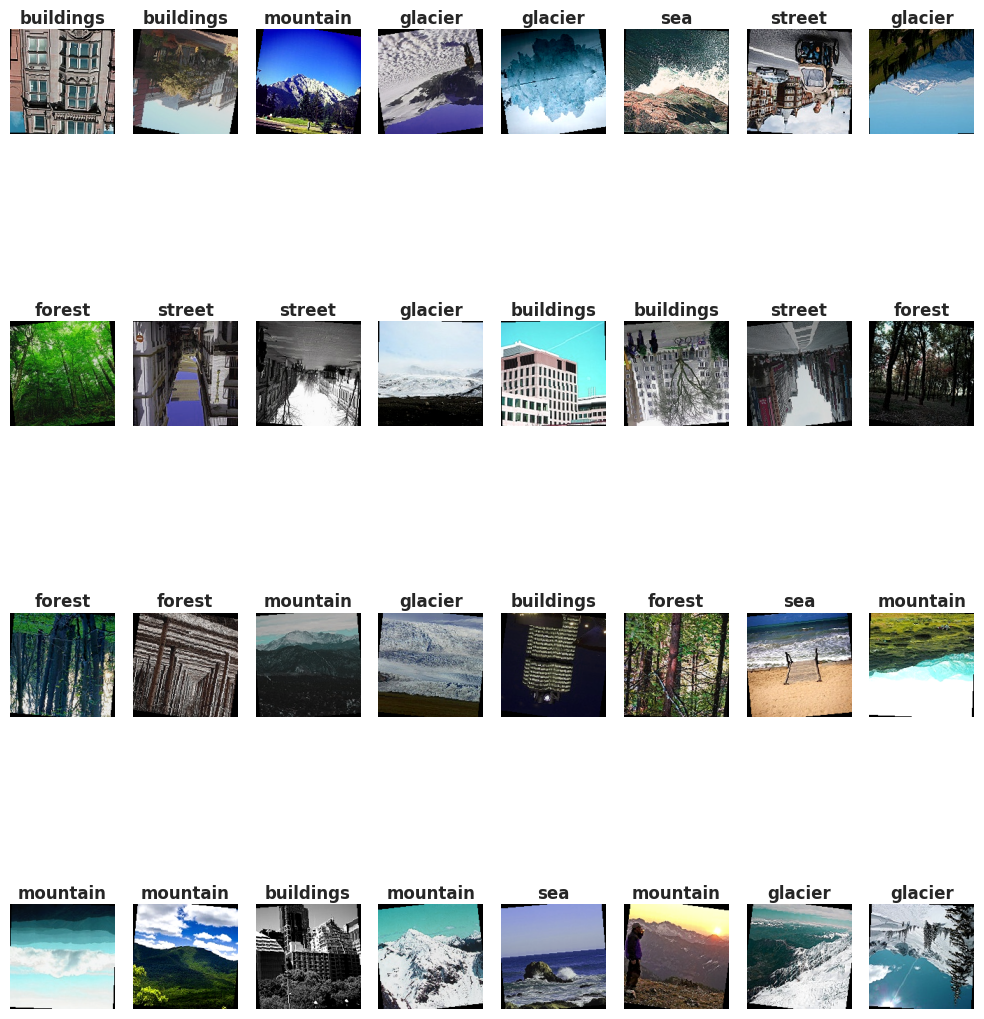

In [16]:
#showing 32 images of one batch
plt.figure(figsize=(10,13))
sns.set_theme(style="darkgrid")
for i in range(32):
    plt.subplot(4,8,i+1)
    plt.imshow(image_batch[i].permute(1,2,0))

    plt.title(train_data.classes[label_batch[i]], fontsize=12, fontweight="bold", pad=4)
    plt.axis(False)

plt.tight_layout()
plt.show()

In [17]:
from torch.nn.modules.activation import ReLU
class intelimagemodel(nn.Module):
  def __init__(self,input_shape,hidden_units,output_shape):
    super().__init__()
    self.cnn_block_1=nn.Sequential(
                                 nn.Conv2d(
                                           in_channels=input_shape,
                                           out_channels=hidden_units,
                                           kernel_size=3,
                                           stride=1,
                                           padding=1
                                           ),
                                 nn.ReLU(),
                                 nn.BatchNorm2d(hidden_units),
                                 nn.Conv2d(
                                           in_channels=hidden_units,
                                           out_channels=hidden_units,
                                           kernel_size=3,
                                           stride=1,
                                           padding=1
                                          ),
                                 nn.ReLU(),
                                 nn.BatchNorm2d(hidden_units),
                                 nn.MaxPool2d(kernel_size=2,
                                              stride=2)
                                 )

    self.cnn_block_2=nn.Sequential(
                                   nn.Conv2d(
                                           in_channels=hidden_units,
                                           out_channels=hidden_units,
                                           kernel_size=3,
                                           stride=1,
                                           padding=1
                                           ),
                                   nn.ReLU(),
                                   nn.BatchNorm2d(hidden_units),
                                   nn.Conv2d(
                                           in_channels=hidden_units,
                                           out_channels=hidden_units,
                                           kernel_size=3,
                                           stride=1,
                                           padding=1
                                           ),
                                   nn.ReLU(),
                                   nn.BatchNorm2d(hidden_units),
                                   nn.MaxPool2d(kernel_size=2,
                                                stride=2)
                                   )

    self.classifer=nn.Sequential(
                                 nn.Flatten(),
                                 nn.Dropout(p=0.3),
                                 nn.Linear(in_features=hidden_units*37*37,
                                           out_features=128),
                                 nn.ReLU(),
                                 nn.Linear(in_features=128,
                                           out_features=output_shape)
                                 )

  def forward(self,x):
      x=self.cnn_block_1(x)
      x=self.cnn_block_2(x)
      x=self.classifer(x)
      return x

intelimagemodel=intelimagemodel(
                                input_shape=3,
                                hidden_units=64,
                                output_shape=6
                                ).to(device)
intelimagemodel

intelimagemodel(
  (cnn_block_1): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (cnn_block_2): Sequential(
    (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifer): Sequential(
   

In [18]:
!pip install torchmetrics
import torchmetrics

loss_fn=nn.CrossEntropyLoss()
optimizer=torch.optim.Adam(params=intelimagemodel.parameters(),
                           weight_decay=1e-4,
                           lr=0.001)
accuracy_fn=torchmetrics.Accuracy(task='multiclass',num_classes=len(train_data.classes)).to(device)

In [19]:
from tqdm.auto import tqdm

ecophs=12

for ecophs in tqdm(range(ecophs)):
  print(f"Epoch: {ecophs}\n-------")
  intelimagemodel.train()
  train_loss,train_acc=0,0
  for batch,(X,y) in enumerate(train_dataloader):
    X,y=X.to(device),y.to(device)

    y_pred=intelimagemodel(X)

    loss=loss_fn(y_pred,y)
    train_loss+=loss.item()
    acc=accuracy_fn(y_pred.argmax(dim=1),y)
    train_acc+=acc.item()

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    # if batch%50==0:
    #   print(f"Looked at {batch*len(X)}/{len(train_dataloader.dataset)} samples")
    #   print(f"Loss for last batch the model looked at is {loss:.4f}")
    #   print(f"Accuracy for the last batch the model looked at is {acc*100:.2f}\n")

  avg_trainloss=train_loss/len(train_dataloader)
  avg_trainacc=train_acc/len(train_dataloader)
  print(f"\n-----------------------Epoch: {ecophs},Avg_Train_loss: {avg_trainloss:.4f}, Avg_Train_acc: {avg_trainacc*100:.4f}-----------------\n")



  0%|          | 0/12 [00:00<?, ?it/s]

Epoch: 0
-------

-----------------------Epoch: 0,Avg_Train_loss: 1.5329, Avg_Train_acc: 54.1651-----------------

Epoch: 1
-------

-----------------------Epoch: 1,Avg_Train_loss: 0.7876, Avg_Train_acc: 70.7250-----------------

Epoch: 2
-------

-----------------------Epoch: 2,Avg_Train_loss: 0.7011, Avg_Train_acc: 74.2249-----------------

Epoch: 3
-------

-----------------------Epoch: 3,Avg_Train_loss: 0.6318, Avg_Train_acc: 77.1743-----------------

Epoch: 4
-------

-----------------------Epoch: 4,Avg_Train_loss: 0.5965, Avg_Train_acc: 78.4888-----------------

Epoch: 5
-------

-----------------------Epoch: 5,Avg_Train_loss: 0.5659, Avg_Train_acc: 79.7132-----------------

Epoch: 6
-------

-----------------------Epoch: 6,Avg_Train_loss: 0.5367, Avg_Train_acc: 81.0238-----------------

Epoch: 7
-------

-----------------------Epoch: 7,Avg_Train_loss: 0.5022, Avg_Train_acc: 82.0749-----------------

Epoch: 8
-------

-----------------------Epoch: 8,Avg_Train_loss: 0.5031, Avg_Tr

In [20]:
test_loss = 0.0
test_acc = 0.0

intelimagemodel.eval()
with torch.inference_mode():
    for X_test, y_test in test_dataloader:
        X_test, y_test = X_test.to(device), y_test.to(device)

        # 1. Forward pass
        test_pred = intelimagemodel(X_test)

        # 2. Calculate loss & accuracy
        test_loss += loss_fn(test_pred, y_test).item()
        test_acc += accuracy_fn(test_pred.argmax(dim=1), y_test).item()

    test_loss /= len(test_dataloader)
    test_acc /= len(test_dataloader)

print(f"\nFinal Test Loss: {test_loss:.4f} | Final Test Acc: {test_acc * 100:.2f}%")


Final Test Loss: 0.4989 | Final Test Acc: 82.93%
